In [27]:
# Importing packages and libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.random import seed
import seaborn as sns
import datetime as dt
import os
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import t
import sklearn
from sklearn import linear_model, preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

In [34]:
df = pd.read_csv('/content/Electicity_Consumption_df.csv')

In [35]:
df.head(12)

,Index,Date,Consumption (kWh),Positive_Growth,Month
0,0,1985-01-01,72.51,False,January
1,1,1985-02-01,70.67,False,February
2,2,1985-03-01,62.45,False,March
3,3,1985-04-01,57.47,False,April
4,4,1985-05-01,55.32,False,May
5,5,1985-06-01,58.09,True,June
6,6,1985-07-01,62.62,True,July
7,7,1985-08-01,63.25,True,August
8,8,1985-09-01,60.58,False,September
9,9,1985-10-01,56.32,False,October


In [36]:
# Because of saving/importing to/from CSV, I see an extra column of index. I am going to delete the extra index column as the very first step:

df = df.drop(columns=['Index'])


In [37]:
df.head(12)

,Date,Consumption (kWh),Positive_Growth,Month
0,1985-01-01,72.51,False,January
1,1985-02-01,70.67,False,February
2,1985-03-01,62.45,False,March
3,1985-04-01,57.47,False,April
4,1985-05-01,55.32,False,May
5,1985-06-01,58.09,True,June
6,1985-07-01,62.62,True,July
7,1985-08-01,63.25,True,August
8,1985-09-01,60.58,False,September
9,1985-10-01,56.32,False,October


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               397 non-null    object 
 1   Consumption (kWh)  397 non-null    float64
 2   Positive_Growth    397 non-null    bool   
 3   Month              397 non-null    object 
dtypes: bool(1), float64(1), object(2)
memory usage: 9.8+ KB


In [39]:
# As .info() shows us, our sample size is 397. We do not have any Null values.

In [40]:
# Let's check datatypes first:

df.dtypes

,0
Date,object
Consumption (kWh),float64
Positive_Growth,bool
Month,object


In [41]:
# Date is object, which is string. We need to change it to date/time type.

df['Date']= pd.to_datetime(df['Date'])

df.dtypes

,0
Date,datetime64[ns]
Consumption (kWh),float64
Positive_Growth,bool
Month,object


In [42]:
# Let's get a mean of consumption:
df['Consumption (kWh)'].mean()
print('The mean of consumption is', df['Consumption (kWh)'].mean(), 'kWh')

# Let's get a median of consumption:
df['Consumption (kWh)'].median()
print('The median of consumption is', df['Consumption (kWh)'].median(), 'kWh')

# Let's calculate standard deviation:
df['Consumption (kWh)'].std()
print('The standard deviation of consumption is', df['Consumption (kWh)'].std(), 'kWh')

The mean of consumption is 88.84722921914357 kWh
The median of consumption is 89.78 kWh
The standard deviation of consumption is 15.387784768483222 kWh


In [43]:
# Mean and Median are very similar.
# The distribution looks normal.

Text(0.5, 1.0, 'Distribution of Consumption')

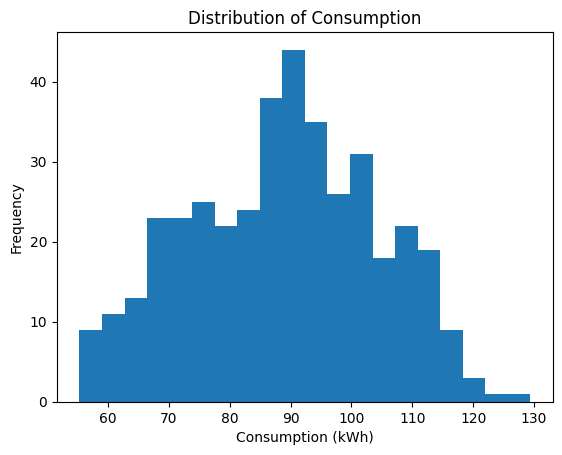

In [44]:
# Let's draw histogram of Consumption (kWh) column

plt.hist(df['Consumption (kWh)'], bins=20)
plt.xlabel('Consumption (kWh)')
plt.ylabel('Frequency')
plt.title('Distribution of Consumption')

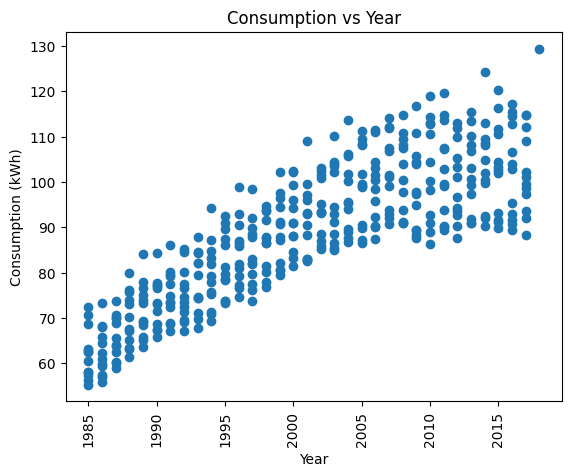

In [45]:
# Let's make a scatterplot of consumption vs months:

plt.scatter(df['Date'].dt.year , df['Consumption (kWh)'] )
plt.xlabel('Year')
plt.ylabel('Consumption (kWh)')
plt.title('Consumption vs Year')
plt.xticks(rotation=90)
plt.show()

In [46]:
# Based on the above scatterplot, it is clear that overall consumption has increased consistently over the last decades.
# This can be explained by population growth, and also can show increase in using electrical devices.
# A pretty strong positive Pearson correlation between year and consumption is obvious from this scatterplot.
# Let's calculate Pearson Correlation Coefficient to get the exact value.

correlation = df['Date'].dt.year.corr(df['Consumption (kWh)'])
print('The Pearson Correlation Coefficient is', correlation)

The Pearson Correlation Coefficient is 0.836796244110617


In [47]:
# Correlation coefficient is 0.83. Even we see a strong positive Pearson correlation here, I still want to know if this relationship between year and consumption didn't just happen by chance.
# So I form my hypothesis:
# H0 (Null Hypothesis): There is no relationship between Year and Consumption Value at this dataset.
# HA (Alternative Hypothesis): There is a significant relationship between Year and Consumption Value.
# My goal is to see if the dataset gives me enough evidence to reject the null hypothes.
# I choose t-Test as my statistic test.

In [48]:
# t-Test
# r = correlation = 0.83
# N = sample size = 397
# t = r * (sqrt(N-2)) / sqrt(1 - r**2)

t = correlation * (np.sqrt(397-2)) / np.sqrt(1-correlation**2)
print('t = ', t)


t =  30.37544885125555


In [49]:
# Now, I need to calculate p-value:

r_value , p_value = stats.pearsonr(df['Date'].dt.year, df['Consumption (kWh)'])
print('r_value is', r_value)
print('p_value is', p_value)

r_value is 0.8367962441106176
p_value is 2.220896836763372e-105


In [50]:
 # Now, we have 3 important values as below:

 # t-statistic = 30.37
 # Pearson Correlation = 0.83
 # p-value = 2.220896836763372e-105

 # p-value is less than 0.05, so I can reject the Null Hypothesis.
 # This means the probability of getting a correlation of 0.84 purely by random chance is less than 5%, giving you confidence the relationship is real.

In [51]:
# We can also calculate 95% confidence interval for the consumption Mean:

# Sample size = 397
# degree of freedom = 397-1 = 396
# Standard deviation = 15.38
# Mean = 88.84
# Confidence level = 95%
# Standard Error = std / sqrt(N)
# For 95% confidence level and 396 degree of freedom, then t-value will be 1.96
# Margin of Error ME = t-value * Standard Error

standard_error = df['Consumption (kWh)'].std() / np.sqrt(397)
margin_of_error = 1.96 * standard_error
lower_limit = df['Consumption (kWh)'].mean() - margin_of_error
upper_limit = df['Consumption (kWh)'].mean() + margin_of_error

print('95% Confidence Interval for Consumption Mean is', lower_limit, 'to', upper_limit)

95% Confidence Interval for Consumption Mean is 87.33353929137094 to 90.3609191469162


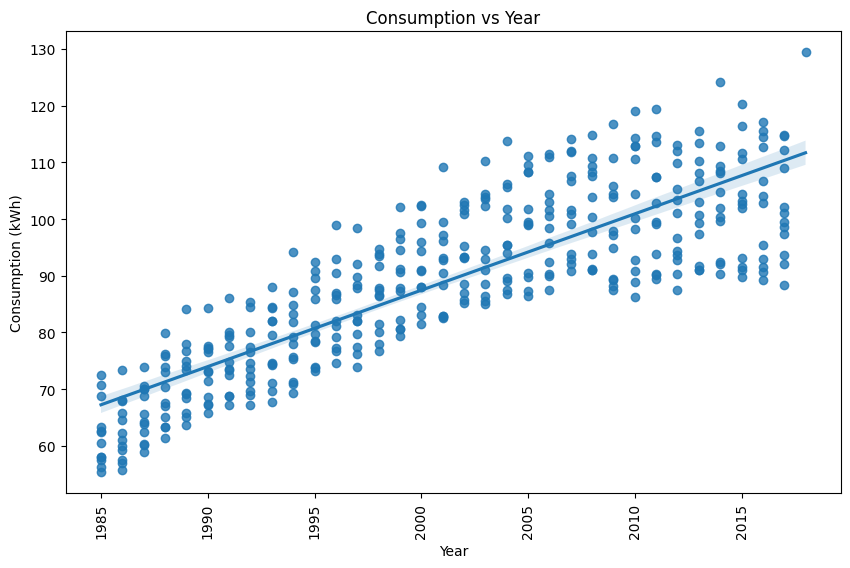

In [52]:
# Now, I want to plot a scatterplot, showing 95% confidence interval on it. I use seaborn for this matter.

plt.figure(figsize=(10,6))
sns.regplot(data=df, x=df['Date'].dt.year , y='Consumption (kWh)', marker='o')
plt.xlabel('Year')
plt.ylabel('Consumption (kWh)')
plt.title('Consumption vs Year')
plt.xticks(rotation=90)
plt.show()

In [54]:
# Now, let's split dataset to warm weather and cold weather months. Warm weather includes April to September, and cold weather include October to March.
# I want to get consumption mean() of each, and compare the two to see whether the difference is meaningful or it is by chance.
# df_cold & df_warm

In [55]:
df_cold = df[df['Date'].dt.month.isin([1,2,3,10,11,12])]
df_warm = df[df['Date'].dt.month.isin([4,5,6,7,8,9])]

In [56]:
df_cold.head(12)

,Date,Consumption (kWh),Positive_Growth,Month
0,1985-01-01,72.51,False,January
1,1985-02-01,70.67,False,February
2,1985-03-01,62.45,False,March
9,1985-10-01,56.32,False,October
10,1985-11-01,58.00,True,November
11,1985-12-01,68.71,True,December
12,1986-01-01,73.31,True,January
13,1986-02-01,67.99,False,February
14,1986-03-01,62.22,False,March
21,1986-10-01,57.53,False,October


In [57]:
df_warm.head(12)

,Date,Consumption (kWh),Positive_Growth,Month
3,1985-04-01,57.47,False,April
4,1985-05-01,55.32,False,May
5,1985-06-01,58.09,True,June
6,1985-07-01,62.62,True,July
7,1985-08-01,63.25,True,August
8,1985-09-01,60.58,False,September
15,1986-04-01,57.03,False,April
16,1986-05-01,55.81,False,May
17,1986-06-01,59.90,True,June
18,1986-07-01,65.77,True,July


In [59]:
# Now, ler's get an average of consumption for each warm and cold dataset.

df_cold['Consumption (kWh)'].mean()
df_warm['Consumption (kWh)'].mean()

print('Consumption average for cold months is', df_cold['Consumption (kWh)'].mean(), 'kWh')
print('Consumption average for warm months is', df_warm['Consumption (kWh)'].mean(), 'kWh')

Consumption average for cold months is 90.59150753768844 kWh
Consumption average for warm months is 87.0941414141414 kWh


In [62]:
# Consumption average for cold months is a bit higher.
# I would like to see if this difference is meaningful, or it is by chance.
# Again, I need to form Hypothesis tests.
# Null Hypothesis H0: There is no significant difference between consumption in cold and warm months.
# Alternative Hypothesis HA: Difference between consumption in cold and warm months is statistically significant.

In [64]:
# I use 'Independent Two-Sample T-Test' in order to compare two datasets: 1)df_cold  2)df_warm

df_cold = df[df['Date'].dt.month.isin([1,2,3,10,11,12])]
df_warm = df[df['Date'].dt.month.isin([4,5,6,7,8,9])]

# t_stat, p_val = stats.ttest_ind(group_A, group_B)

t_stat, p_val = stats.ttest_ind(df_cold['Consumption (kWh)'], df_warm['Consumption (kWh)'])

print('t_stat is', t_stat)
print('p_val is', p_val)

t_stat is 2.276195451314016
p_val is 0.023368847441774504


In [65]:
# Since the p-value is about 2% and it is less than 5%, therefore I can reject the Null Hypothesis.
# So I adopt the alternative hypothesis (HA) which believes the difference in consumption between cold months and warm months is stitistically significant.
# As conclusion, the average electricity consumption in cold months is higher than warm months.